In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("rfm_segments.csv")
df.head()

,Customer ID,Recency,Frequency,Monetary,Cluster,Segment
0,12347,1,8,4921.53,1,Loyal customers
1,12348,74,5,2019.40,2,Champions
2,12349,18,4,4428.69,1,Loyal customers
3,12350,309,1,334.40,0,Potential loyalists
4,12351,374,1,300.93,0,Potential loyalists


In [3]:
print(df.shape)
print(df.columns.tolist())

(4989, 6)
['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']


In [4]:
#check no of churned customers 

df['Churn'] = (df['Segment']=='At risk').astype(int)
df['Churn'].value_counts()

Churn
0    4591
1     398
Name: count, dtype: int64

In [5]:
df['Churn'].value_counts(normalize = True)*100

Churn
0    92.022449
1     7.977551
Name: proportion, dtype: float64

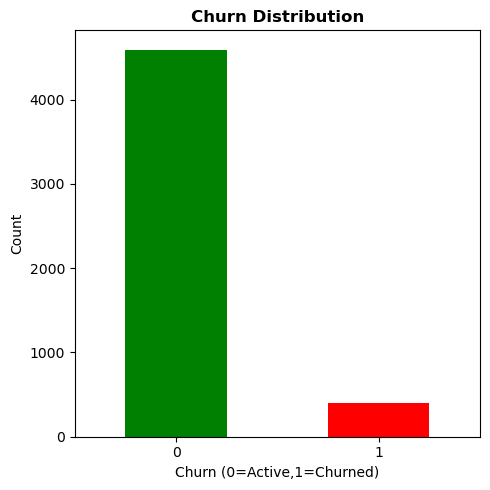

In [6]:
plt.figure(figsize=(5,5))
df['Churn'].value_counts().plot(kind = 'bar' , color = ["green",'red'])
plt.title("Churn Distribution" , fontsize = 12 , fontweight ='bold')
plt.xlabel("Churn (0=Active,1=Churned)")
plt.ylabel('Count')
plt.xticks(rotation = 0)
plt.tight_layout()
# plt.grid(True)
plt.show()

In [7]:
x = df[['Recency' , 'Frequency', 'Monetary']]
y = df['Churn']

In [8]:
print(x.shape) 
print(y.shape)

(4989, 3)
(4989,)


In [9]:
#train test split 
from sklearn.model_selection import train_test_split
x = df[['Recency' , 'Frequency', 'Monetary']]
y = df['Churn']
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(3991, 3)
(998, 3)
(3991,)
(998,)


**It is very mendatory to apply SMOTE as the data is very imbalanced**

**ACTIVE = 86.6% and AT RISK = 13.4 %** , 
**APPLYING SMOTE**

In [11]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42) #model 
x_train_sm , y_train_sm = sm.fit_resample(x_train , y_train)  #balanced the testing data 

**Check counting before and after smote**

In [12]:
print("Before Smote:", y_train.value_counts().to_dict())
print("After Smote:", y_train_sm.value_counts().to_dict())

Before Smote: {0: 3680, 1: 311}
After Smote: {0: 3680, 1: 3680}


**XG BOOST MODEL**

In [13]:
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators = 100 , learning_rate=0.1,max_depth=4,random_state=42)
model.fit(x_train_sm,y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

**MODEL EVALUATION USING ROC-AUC SCORE**

In [14]:
from sklearn.metrics import roc_auc_score , classification_report , confusion_matrix
y_pred = model.predict(x_test)
# print(y_pred) 
y_prob = model.predict_proba(x_test)[:,1]
# y_prob 
auc = roc_auc_score(y_test , y_prob)
auc

np.float64(0.9998738281792143)

In [15]:
cm = confusion_matrix(y_test , y_pred)
cm

array([[909,   2],
       [  2,  85]])

**CHECKING FOR OVERFITTING TRAINING AND TESTING ACCURACY**

In [16]:
train_score = model.score(x_train_sm , y_train_sm)
print(train_score)
test_score = model.score(x_test , y_test)
print(test_score)

print('No overfitting❌')

0.996195652173913
0.9959919839679359
No overfitting❌


**CHECKING PRECISION @TOP20%**

In [17]:
top_20 = int(0.20*len(y_test))  #taking top 20 customers 
indices = np.argsort(y_prob)[::-1][:top_20] 
precision_top_20 = y_test.iloc[indices].sum()/top_20
precision_top_20

np.float64(0.4371859296482412)

In [18]:
!pip install shap

In [19]:
import shap

**SHAP VALUES**

In [20]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_test)

**Shap Summary plot**

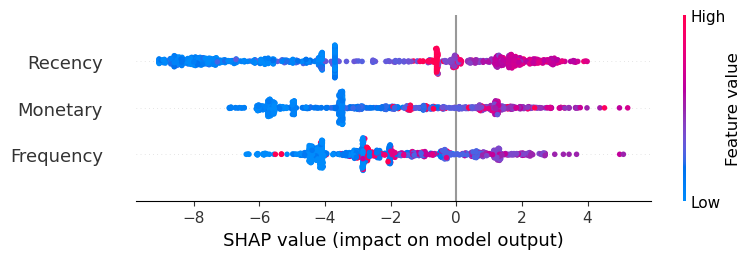

In [21]:
shap.summary_plot(shap_values , x_test)

**Bar plot**

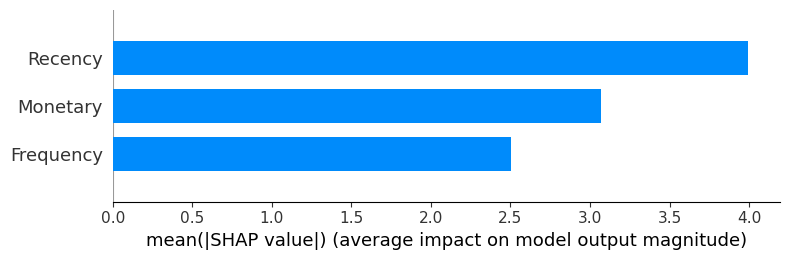

In [22]:
shap.summary_plot(shap_values , x_test , plot_type='bar')

**TESTING**

In [24]:
new_customer = pd.DataFrame({
    'Recency':[180], 
    'Frequency':[4], 
    'Monetary':[1500]
})

pred = model.predict(new_customer)
print("At Risk"if pred[0]==1 else "Active")

Active


**LIST OF AT RISK CUSTOMER**

In [26]:
at_risk = df[df['Churn']==1]
at_risk.to_csv('at_risk_customer.csv' , index = False)

In [27]:
import pickle
with open('churn_model.pkl','wb') as f:
    pickle.dump(model , f)
print("Your model is saved")

Your model is saved
